In [1]:
import os
import sys
import copy

sys.path.append('/home/fboehning/fboehning') #path to beesup_llm

import beesup_llm
import beesup_llm.llm; from beesup_llm.llm import *
import beesup_llm.emb; from beesup_llm.emb import *
import beesup_llm.injection; from beesup_llm.injection import *
import beesup_llm.injection.rag; from beesup_llm.injection.rag import *

import beesup_llm.toolkit.display_settings; from beesup_llm.toolkit.display_settings import *

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import importlib

BEESUP_LLM=[
    'beesup_llm',
    'beesup_llm.llm',
    'beesup_llm.emb',
    'beesup_llm.injection',
    'beesup_llm.injection.rag',
    'beesup_llm.toolkit.display_settings'
]

def reimport(pathlist=BEESUP_LLM):

    for module_path in pathlist:
        if module_path in sys.modules:
            # Reload if the module is already imported
            importlib.reload(sys.modules[module_path])
        else:
            importlib.import_module(module_path)
            # Import the module or submodule for the first time
            globals()[module_path.split('.')[0]] = importlib.import_module(module_path)

        module = sys.modules[module_path]
        globals().update({name: getattr(module, name) for name in dir(module) if not name.startswith('_')})

import logging
logging.basicConfig(
    level=logging.INFO,
    #level=logging.DEBUG,
    format='%(asctime)s - %(filename)s - %(name)s - %(funcName)s - %(levelname)s - %(message)s')

def set_info(pathlist=BEESUP_LLM):

    for path in pathlist:
        logger = logging.getLogger(path)
        logger.setLevel(logging.INFO)
        logging.getLogger().setLevel(logging.INFO)

def set_debug(pathlist=BEESUP_LLM):
    for path in pathlist:
        logger = logging.getLogger(path)
        logger.setLevel(logging.DEBUG)
        logging.getLogger().setLevel(logging.DEBUG)

set_info()
reimport()

In [19]:
#https://huggingface.co/nvidia/NV-Embed-v2/discussions/37

import torch; print(f"{torch.__version__=}")
import transformers; print(f"{transformers.__version__=}")

import flash_attn; print(f"{flash_attn.__version__=}")
import accelerate; print(f"{accelerate.__version__=}") #importent!!
import bitsandbytes; print(f"{bitsandbytes.__version__=}")

torch.__version__='2.3.1'
transformers.__version__='4.43.1'
flash_attn.__version__='2.6.3'
accelerate.__version__='0.33.0'
bitsandbytes.__version__='0.45.2'


# Loading Embedding- & and LLM Pipeline

In [3]:
# Loading Embedding Pipeline
emb_pipe=NVEmbedPipeline()
emb_pipe.load_model()
emb_model=copy.deepcopy(emb_pipe.model)

2025-03-05 12:40:24,232 - emb.py - beesup_llm.emb - load_model - INFO - Loading model nvidia/NV-Embed-v2
2025-03-05 12:40:25,044 - config.py - datasets - <module> - INFO - PyTorch version 2.3.1 available.
2025-03-05 12:40:26,288 - modeling.py - accelerate.utils.modeling - get_balanced_memory - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [4]:
llm_pipe=LlamaPipeline()
llm_pipe.prepare_inference()
llm_model=copy.deepcopy(llm_pipe.model)

2025-03-05 12:40:37,447 - llm.py - beesup_llm.llm - load_model - INFO - Loading model meta-llama/Meta-Llama-3.1-8B-Instruct
2025-03-05 12:40:38,076 - modeling.py - accelerate.utils.modeling - get_balanced_memory - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

# Prepare Knowledge-Chunks

In [ ]:
# Load chunks from wikipedia
from langchain_community.document_loaders import WikipediaLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

docs = WikipediaLoader(query='Technische Universität Ilmenau', lang='de', load_max_docs=4).load()
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
chunks = splitter.split_documents(docs)

chunks_df=pd.DataFrame(
    dict(
        page_content = [c.page_content for c in chunks],
        summary = [c.metadata['summary'] for c in chunks],
        title = [c.metadata['title'] for c in chunks],
        source = [c.metadata['source'] for c in chunks]))


CHUNK_TEMPLATE="TITLE: {title}\n\nSUMMARY: {summary}\n\nCONTENT: {page_content}"

chunks_df['chunk']=chunks_df.apply(lambda x: CHUNK_TEMPLATE.format(**x), axis=1)
chunks_df['n_chars']=chunks_df['chunk'].apply(len)
chunks_df.head(4)

,page_content,summary,title,source,chunk,n_chars
0,Die Technische Universität Ilmenau ist eine Un...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,845
1,Forschung und Lehre sind stark ingenieurwissen...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,800
2,== Fakultäten ==\nElektrotechnik und Informati...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,767
3,== Schwerpunkte in der Forschung ==\n\nDie tra...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,753
4,Funktionale Materialien und Technologien\nInte...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,695
...,...,...,...,...,...,...
80,Seit den Eingemeindungen von 2018 und 2019 geh...,Die Goethe- und Universitätsstadt Ilmenau lieg...,Ilmenau,https://de.wikipedia.org/wiki/Ilmenau,TITLE: Ilmenau\n\nSUMMARY: Die Goethe- und Uni...,1764
81,die Hauptwasserscheide dar zwischen der Elbe (...,Die Goethe- und Universitätsstadt Ilmenau lieg...,Ilmenau,https://de.wikipedia.org/wiki/Ilmenau,TITLE: Ilmenau\n\nSUMMARY: Die Goethe- und Uni...,1663
82,Der Einzugsbereich der Elbe (übriges Stadtgebi...,Die Goethe- und Universitätsstadt Ilmenau lieg...,Ilmenau,https://de.wikipedia.org/wiki/Ilmenau,TITLE: Ilmenau\n\nSUMMARY: Die Goethe- und Uni...,1772
83,fließt. In östlicher Richtung folgen noch die ...,Die Goethe- und Universitätsstadt Ilmenau lieg...,Ilmenau,https://de.wikipedia.org/wiki/Ilmenau,TITLE: Ilmenau\n\nSUMMARY: Die Goethe- und Uni...,1768


In [6]:
# add embedding column to chunks_df (inplace)
emb_pipe.add_emb(
    chunks_df,
    txt_key='chunk',
    emb_key='emb',
    batch_size=16,
    instruction=None,
    verbose=True
    )

chunks_df

,page_content,summary,title,source,chunk,n_chars,emb
0,Die Technische Universität Ilmenau ist eine Un...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,845,"[-0.019536521, 0.029811548, 0.017637635, 0.002..."
1,Forschung und Lehre sind stark ingenieurwissen...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,800,"[-0.01733121, 0.029994125, 0.017499637, 0.0007..."
2,== Fakultäten ==\nElektrotechnik und Informati...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,767,"[-0.013339509, 0.02743268, 0.016128493, -0.000..."
3,== Schwerpunkte in der Forschung ==\n\nDie tra...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,753,"[-0.01610139, 0.023838801, 0.015326084, 0.0053..."
4,Funktionale Materialien und Technologien\nInte...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,695,"[-0.0147999525, 0.027407553, 0.013766218, -0.0..."
...,...,...,...,...,...,...,...
80,Seit den Eingemeindungen von 2018 und 2019 geh...,Die Goethe- und Universitätsstadt Ilmenau lieg...,Ilmenau,https://de.wikipedia.org/wiki/Ilmenau,TITLE: Ilmenau\n\nSUMMARY: Die Goethe- und Uni...,1764,"[0.011917645, 0.026250415, 0.016104292, 0.0041..."
81,die Hauptwasserscheide dar zwischen der Elbe (...,Die Goethe- und Universitätsstadt Ilmenau lieg...,Ilmenau,https://de.wikipedia.org/wiki/Ilmenau,TITLE: Ilmenau\n\nSUMMARY: Die Goethe- und Uni...,1663,"[0.010898571, 0.025798833, 0.014740734, 0.0050..."
82,Der Einzugsbereich der Elbe (übriges Stadtgebi...,Die Goethe- und Universitätsstadt Ilmenau lieg...,Ilmenau,https://de.wikipedia.org/wiki/Ilmenau,TITLE: Ilmenau\n\nSUMMARY: Die Goethe- und Uni...,1772,"[0.012481496, 0.026877984, 0.011606619, 0.0044..."
83,fließt. In östlicher Richtung folgen noch die ...,Die Goethe- und Universitätsstadt Ilmenau lieg...,Ilmenau,https://de.wikipedia.org/wiki/Ilmenau,TITLE: Ilmenau\n\nSUMMARY: Die Goethe- und Uni...,1768,"[0.018369414, 0.025032401, 0.01744325, 0.00565..."


# RAG-Pipeline

In [250]:
reimport()

In [251]:
reimport()
emb_pipe=EMBPipeline.from_model(emb_model)
llm_pipe=LLMPipeline.from_model(llm_model)
llm_pipe.prepare_inference()
reimport()

In [7]:
rag_pipe=RAGPipeline(
    chunks_df=chunks_df,
    llm_pipe=llm_pipe,
    emb_pipe=emb_pipe,
    limiters=[NumLimiter(100),TokenLimiter(1000), KneeLimiter()]
    )

In [8]:
query_txt="Kann man an der TU Ilmenau Informatik studieren?"

response=rag_pipe(query_txt, stream=True)

Ja, an der Technischen Universität Ilmenau kann man Informatik studieren. In der Fakultät "Informatik und Automatisierung" werden entsprechende Studiengänge angeboten.

<module 'matplotlib.pyplot' from '/home/fboehning/.conda/envs/beesup7/lib/python3.12/site-packages/matplotlib/pyplot.py'>

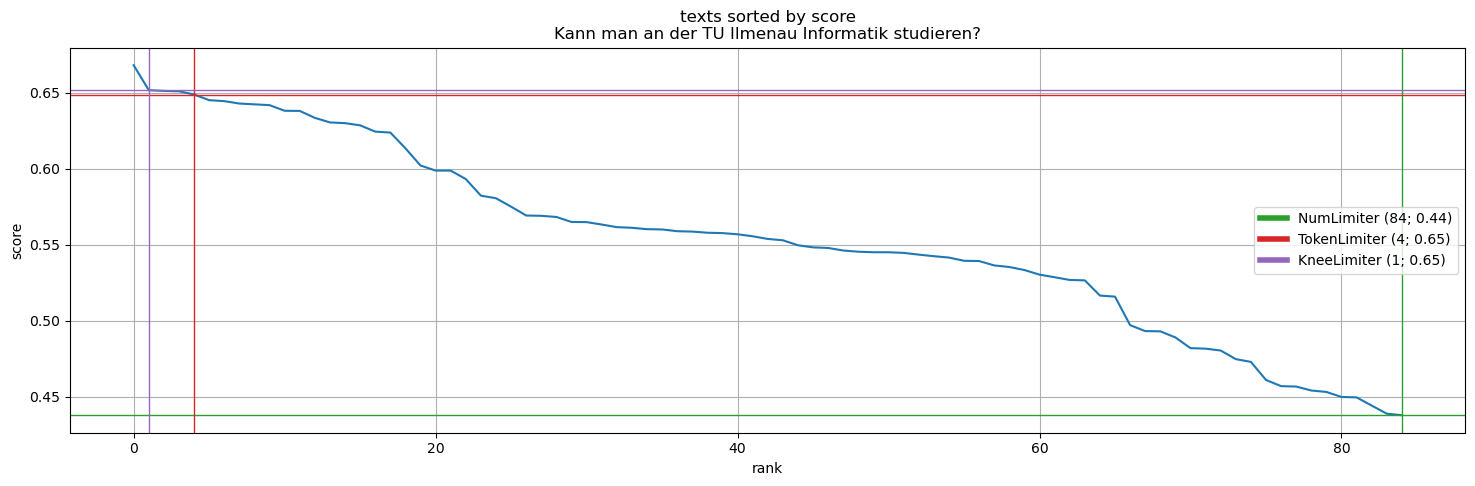

In [ ]:
# plot the ranking of recent query: Chunks sorted by score, visualite limiters
rag_pipe._plot

In [11]:
# plot the ranking chunks of recent query
rag_pipe._ranking

,chunk,emb,n_tokens,score,NumLimiter,n_tokens_cumsum,TokenLimiter,KneeLimiter
2,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.013339509, 0.02743268, 0.016128493, -0.000...",204,0.668216,True,204,True,True
4,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.0147999525, 0.027407553, 0.013766218, -0.0...",182,0.651782,True,386,True,True
5,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.017784286, 0.027176835, 0.016489327, -0.00...",211,0.651303,True,597,True,False
16,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.01411097, 0.02966845, 0.0143569475, -0.004...",206,0.651050,True,803,True,False
9,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.021085802, 0.030478392, 0.017486135, 0.002...",178,0.648930,True,981,True,False
